In [28]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [29]:
# DATA LOADING - automatically find the CSV file inside /kaggle/input

import glob
import os

# Find all CSV files under /kaggle/input (including subfolders)
csv_files = glob.glob(r"C:\Users\kunal\Downloads\heart_disease_uci.csv", recursive=True)
print("CSV files found:", csv_files)

# Use the first CSV file found
data_path = csv_files[0]
print("Using data file:", data_path)

df = pd.read_csv(data_path)

print("Shape of dataset:", df.shape)
df.head()


CSV files found: ['C:\\Users\\kunal\\Downloads\\heart_disease_uci.csv']
Using data file: C:\Users\kunal\Downloads\heart_disease_uci.csv
Shape of dataset: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)


In [30]:
# Basic information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [31]:
# Statistical summary
df.describe(include='all')


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
count,920.000000,920.000000,920,920,920,861.000000,890.000000,830,918,865.000000,865,858.000000,611,309.000000,434,920.000000
unique,NaN,NaN,2,4,4,NaN,NaN,2,3,NaN,2,NaN,3,NaN,3,NaN
top,NaN,NaN,Male,Cleveland,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,NaN,normal,NaN
freq,NaN,NaN,726,304,496,NaN,NaN,692,551,NaN,528,NaN,345,NaN,196,NaN
mean,460.500000,53.510870,NaN,NaN,NaN,132.132404,199.130337,NaN,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN,0.995652
std,265.725422,9.424685,NaN,NaN,NaN,19.066070,110.780810,NaN,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN,1.142693
min,1.000000,28.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN,0.000000
25%,230.750000,47.000000,NaN,NaN,NaN,120.000000,175.000000,NaN,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
50%,460.500000,54.000000,NaN,NaN,NaN,130.000000,223.000000,NaN,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN,1.000000
75%,690.250000,60.000000,NaN,NaN,NaN,140.000000,268.000000,NaN,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN,2.000000


In [32]:
# Checking missing values
df.isna().sum()


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [33]:
# Let's find columns containing "condition" or similar
df.columns


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [34]:
# Automatically detect target column
possible_targets = ['condition', 'target', 'num', 'diagnosis']

target_col = None
for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

print("Detected target column:", target_col)


Detected target column: num


In [35]:
# If your target column is string-based (like "presence"/"absence"), convert to 0/1
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].map({'healthy': 0, 'presence': 1, 'absence': 0, 
                                         'disease': 1, 'no disease': 0}).fillna(1).astype(int)

df[target_col].value_counts()


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

## Visual EDA


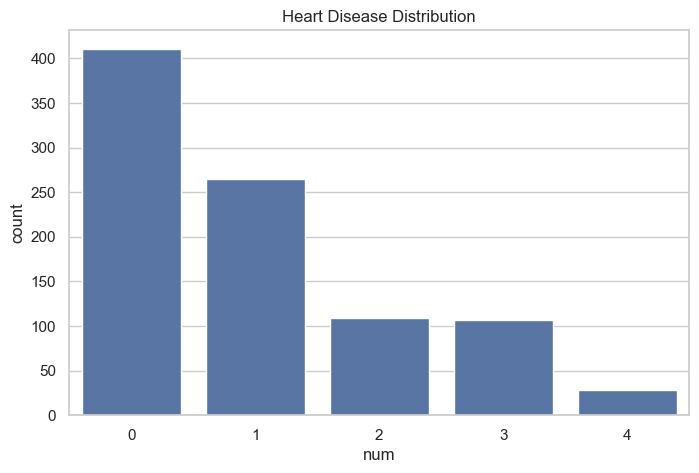

In [36]:
# Target distribution
sns.countplot(data=df, x=target_col)
plt.title("Heart Disease Distribution")
plt.show()


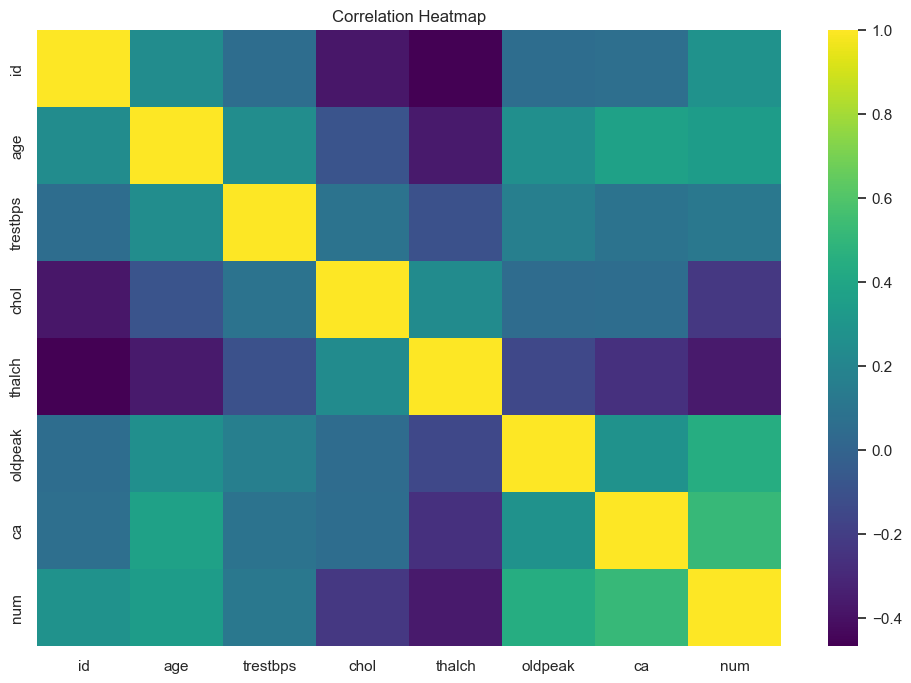

In [37]:
# Correlation heatmap (only numeric columns)
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=False, cmap='viridis')
plt.title("Correlation Heatmap")
plt.show()


## Data Cleaning and Preprocessing


In [38]:
# Drop ID/dataset columns if present (they are not useful for ML)
drop_cols = ['id', 'dataset']
for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [39]:
# Separate features and labels
X = df.drop(columns=[target_col])
y = df[target_col]


In [40]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)
print("Shape after encoding:", X_encoded.shape)


Shape after encoding: (920, 18)


In [41]:
from sklearn.impute import SimpleImputer

# Impute missing values with the median for each column
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_encoded)

print("Shape after imputation:", X_imputed.shape)


Shape after imputation: (920, 18)


In [42]:
# Scaling on the imputed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


In [43]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape



((736, 18), (184, 18))

## Model Training


In [44]:
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_test)


In [45]:
# 2. Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


In [46]:
# 3. SVM
svm_clf = SVC(kernel='rbf')
svm_clf.fit(X_train, y_train)
pred_svm = svm_clf.predict(X_test)


## Model Evaluation


In [47]:
models = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf,
    "SVM": pred_svm
}

results = {}

for name, pred in models.items():
    results[name] = accuracy_score(y_test, pred)

results


{'Logistic Regression': 0.592391304347826,
 'Random Forest': 0.5489130434782609,
 'SVM': 0.6086956521739131}

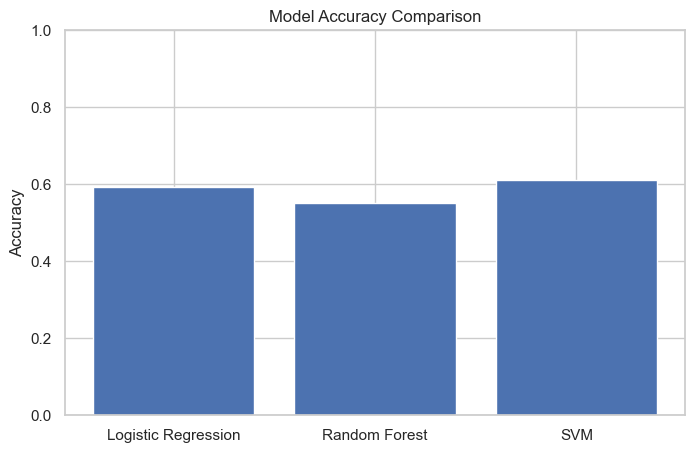

In [48]:
# Plot accuracies
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


In [49]:
best_model = max(results, key=results.get)
print("Best Model:", best_model)
print("Accuracy:", results[best_model])


Best Model: SVM
Accuracy: 0.6086956521739131


## Conclusion

This project uses machine learning to predict heart disease using patient health features.  
Three models were trained: Logistic Regression, Random Forest, and SVM.  
The best-performing model was selected based on accuracy.  
This demonstrates the usefulness of ML in early medical diagnosis.
